importar librerias

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import missingno 
import scipy
import matplotlib.pyplot as plt

importar el data set + analisis rapido

In [3]:
df = pd.read_csv("train.csv")
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.7980
9796,9797,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.3680
9797,9798,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.1880
9798,9799,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.3760


limpieza de datos

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [5]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [6]:
df.describe(include="object")

/tmp/ipykernel_3062/702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name
count,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800
unique,4922,1230,1326,4,793,793,3,1,529,49,4,1861,3,17,1849
top,CA-2018-100111,05/09/2017,26/09/2018,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope
freq,14,38,34,5859,35,35,5101,9800,891,1946,3140,19,5909,1492,47


verificacion de datos nulos

In [7]:
df.isna().sum().sum()

np.int64(11)

<Axes: >

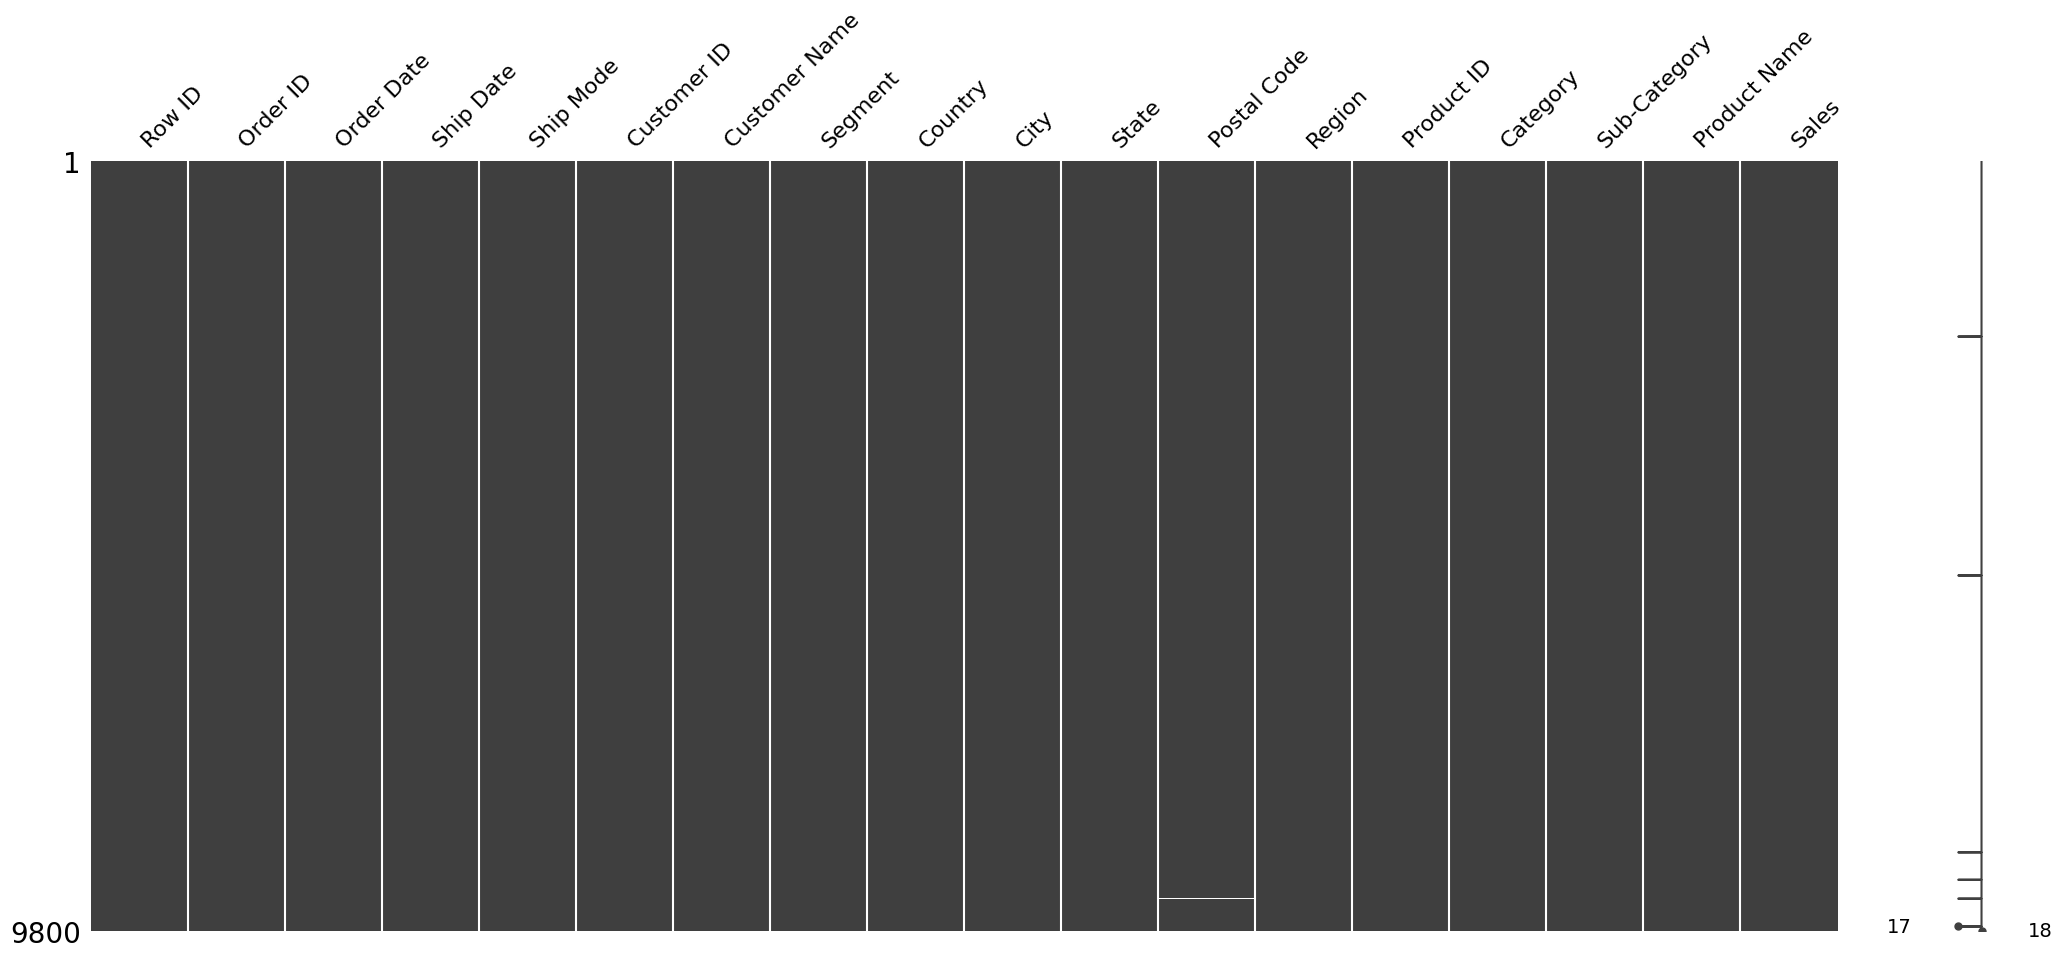

In [8]:
missingno.matrix(df)

In [9]:
df.loc[df["Postal Code"].isna()]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
2234,2235,CA-2018-104066,05/12/2018,10/12/2018,Standard Class,QJ-19255,Quincy Jones,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10001013,Technology,Accessories,Logitech ClearChat Comfort/USB Headset H390,205.03
5274,5275,CA-2016-162887,07/11/2016,09/11/2016,Second Class,SV-20785,Stewart Visinsky,Consumer,United States,Burlington,Vermont,NaN,East,FUR-CH-10000595,Furniture,Chairs,Safco Contoured Stacking Chairs,715.20
8798,8799,US-2017-150140,06/04/2017,10/04/2017,Standard Class,VM-21685,Valerie Mitchum,Home Office,United States,Burlington,Vermont,NaN,East,TEC-PH-10002555,Technology,Phones,Nortel Meridian M5316 Digital phone,1294.75
9146,9147,US-2017-165505,23/01/2017,27/01/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10002926,Technology,Accessories,Logitech Wireless Marathon Mouse M705,99.98
9147,9148,US-2017-165505,23/01/2017,27/01/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-AR-10003477,Office Supplies,Art,4009 Highlighters,8.04
9148,9149,US-2017-165505,23/01/2017,27/01/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-ST-10001526,Office Supplies,Storage,Iceberg Mobile Mega Data/Printer Cart,1564.29
9386,9387,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10000157,Office Supplies,Paper,Xerox 191,79.92
9387,9388,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10001970,Office Supplies,Paper,Xerox 1881,12.28
9388,9389,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-AP-10000828,Office Supplies,Appliances,Avanti 4.4 Cu. Ft. Refrigerator,542.94
9389,9390,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-EN-10001509,Office Supplies,Envelopes,Poly String Tie Envelopes,2.04


podemos ver que hay una relacion en los datos faltantes, vienen de burlington, vermont. pero ya que no tenemos otros datos haremos una imputacion por mean, ya que el codigo postal no sera tan importante para este analisis

In [10]:
df["Postal Code"] = df["Postal Code"].fillna(df["Postal Code"].mean())

In [11]:
df.isna().sum().sum()

np.int64(0)

VERIFICAR DUPLICADOS

In [12]:
df.loc["Ship Mode":,].duplicated().sum()

np.int64(0)

ANALISIS UNIVARIADO

In [13]:
def plots(df):
    paletas_simp = np.array(["pink","inferno"])
    for x in df.columns:
        plt.figure(figsize=(6,10))
        if pd.api.types.is_numeric_dtype(df[x]):
            print(f"variable :{x}")
            sns.histplot(df[x],palette=np.random.choice(paletas_simp))
            plt.show()
            sns.boxenplot(x=df[x],palette=np.random.choice(paletas_simp))
            plt.show()
        else:
            print(f"variable: {x}")
            top = df[x].value_counts(ascending=False).head()
            sns.barplot(x=top.values, y=top.index,palette=np.random.choice(paletas_simp))
            plt.show()
    

variable :Row ID


/tmp/ipykernel_3062/49709752.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[x],palette=np.random.choice(paletas_simp))


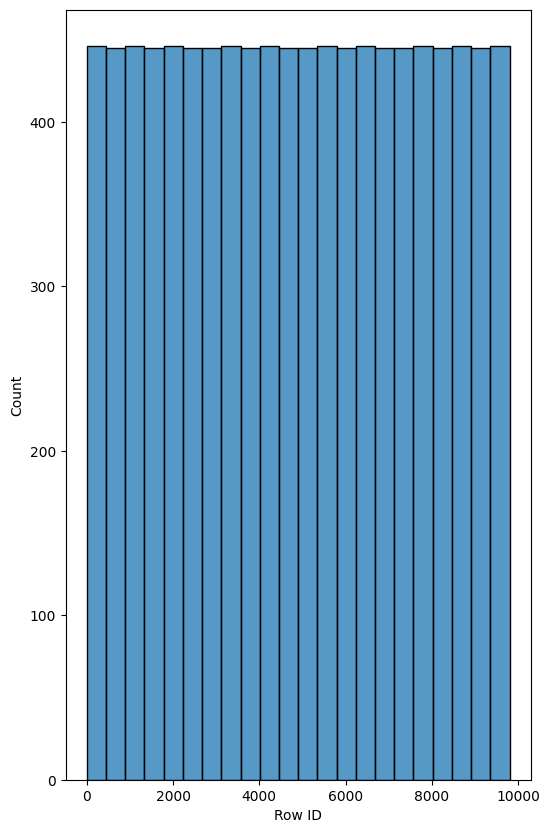

/tmp/ipykernel_3062/49709752.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=df[x],palette=np.random.choice(paletas_simp))


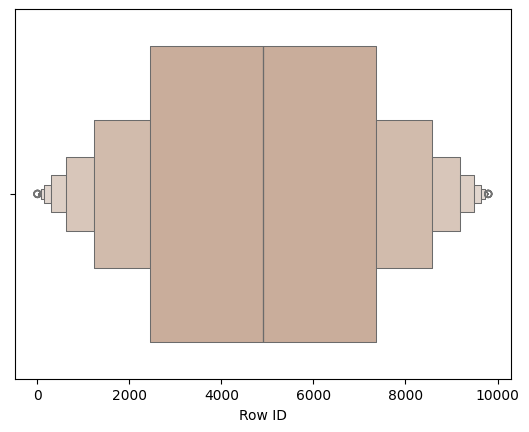

variable: Order ID


/tmp/ipykernel_3062/49709752.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top.values, y=top.index,palette=np.random.choice(paletas_simp))


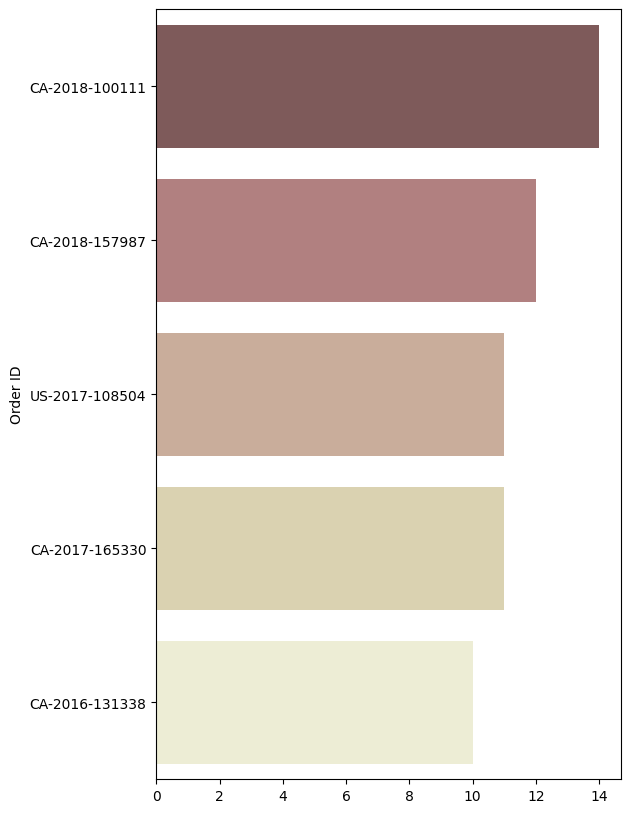

/tmp/ipykernel_3062/49709752.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top.values, y=top.index,palette=np.random.choice(paletas_simp))


variable: Order Date


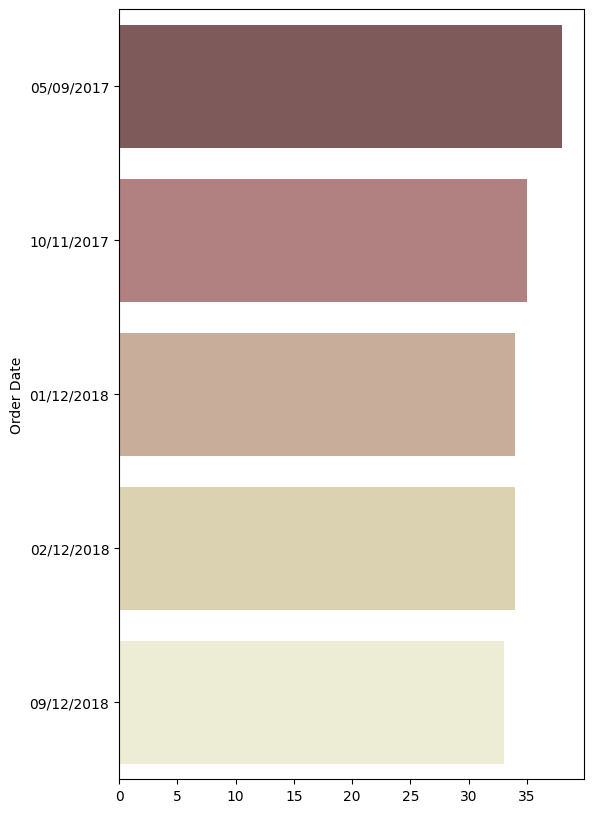

variable: Ship Date


/tmp/ipykernel_3062/49709752.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top.values, y=top.index,palette=np.random.choice(paletas_simp))


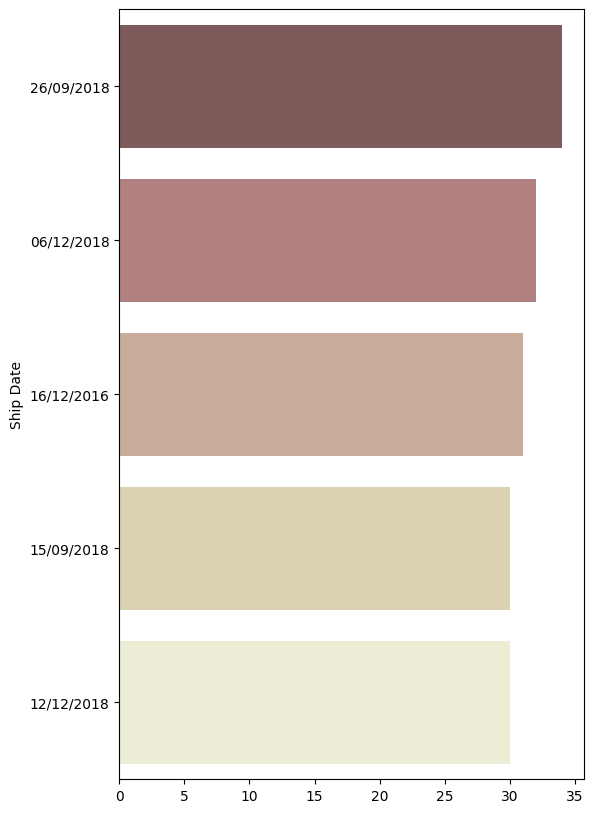

variable: Ship Mode


/tmp/ipykernel_3062/49709752.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top.values, y=top.index,palette=np.random.choice(paletas_simp))


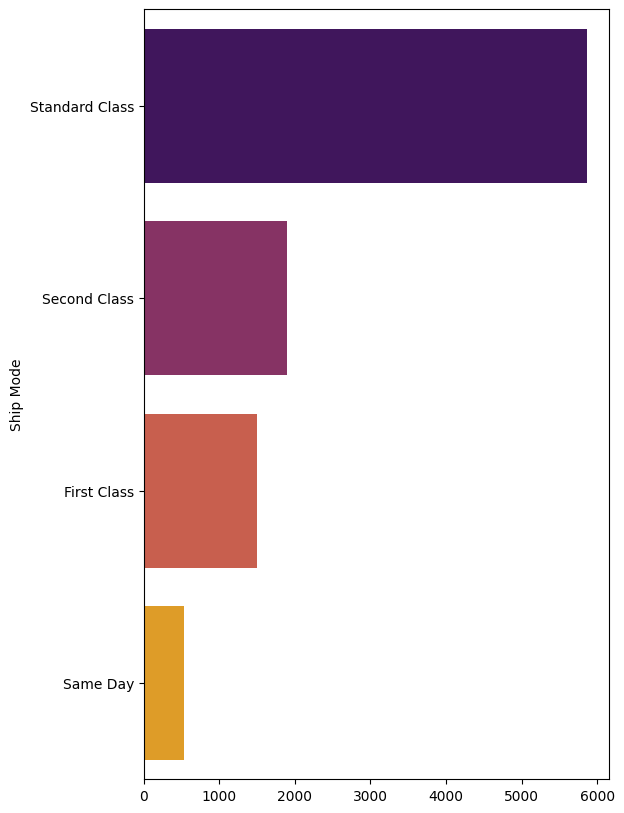

variable: Customer ID


/tmp/ipykernel_3062/49709752.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top.values, y=top.index,palette=np.random.choice(paletas_simp))


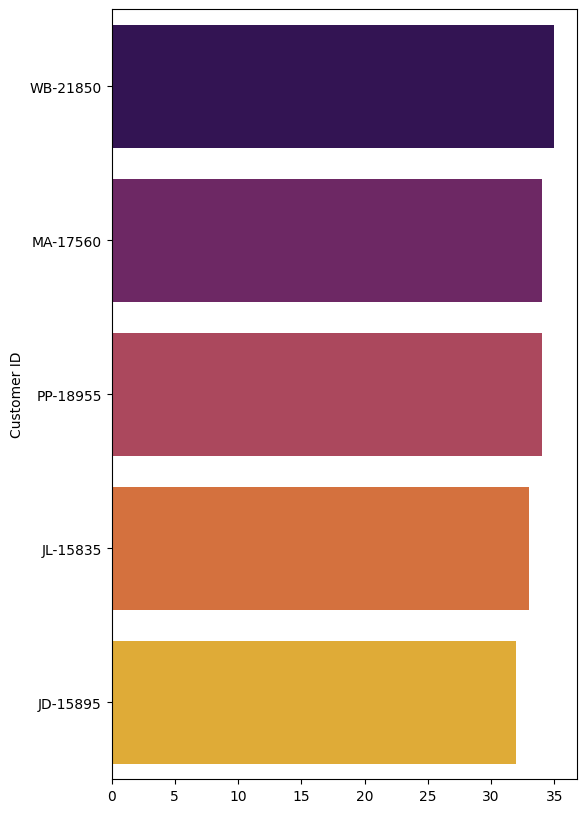

variable: Customer Name


/tmp/ipykernel_3062/49709752.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top.values, y=top.index,palette=np.random.choice(paletas_simp))


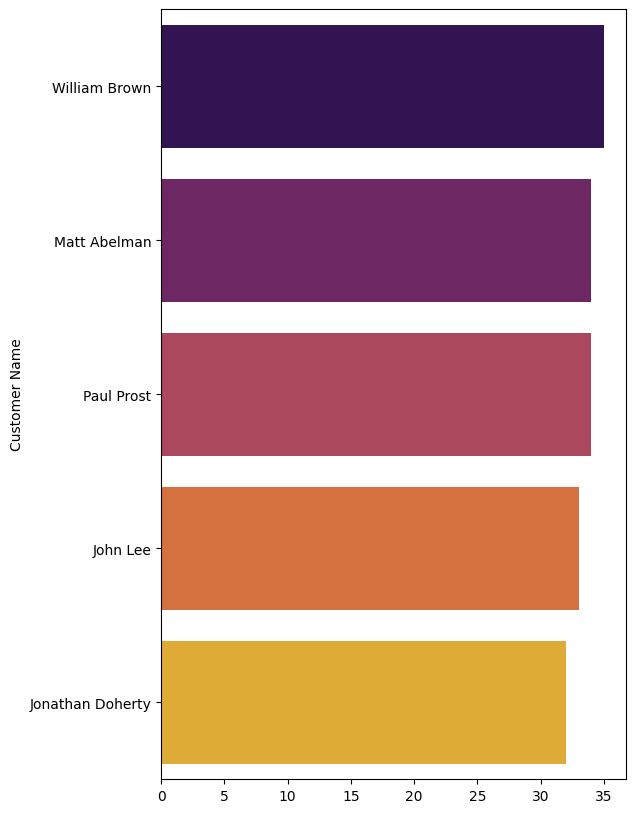

variable: Segment


/tmp/ipykernel_3062/49709752.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top.values, y=top.index,palette=np.random.choice(paletas_simp))


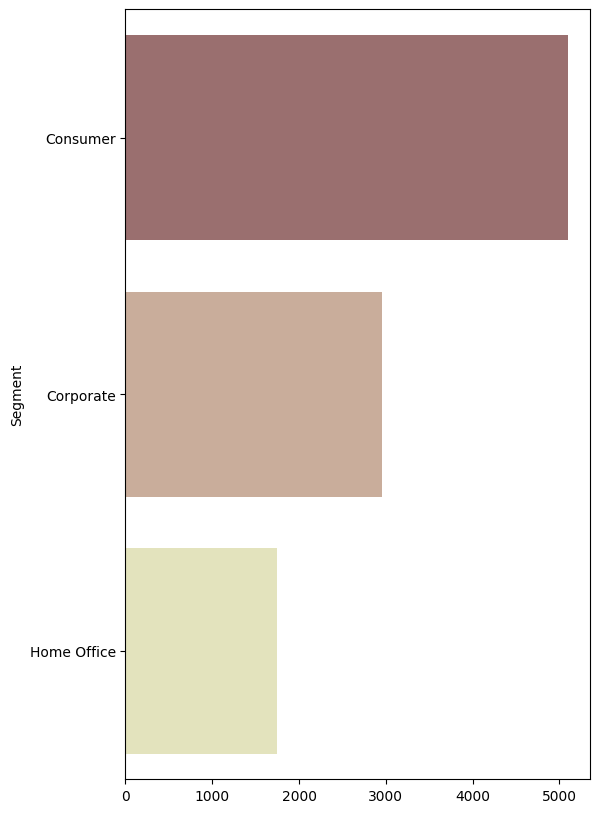

variable: Country


/tmp/ipykernel_3062/49709752.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top.values, y=top.index,palette=np.random.choice(paletas_simp))


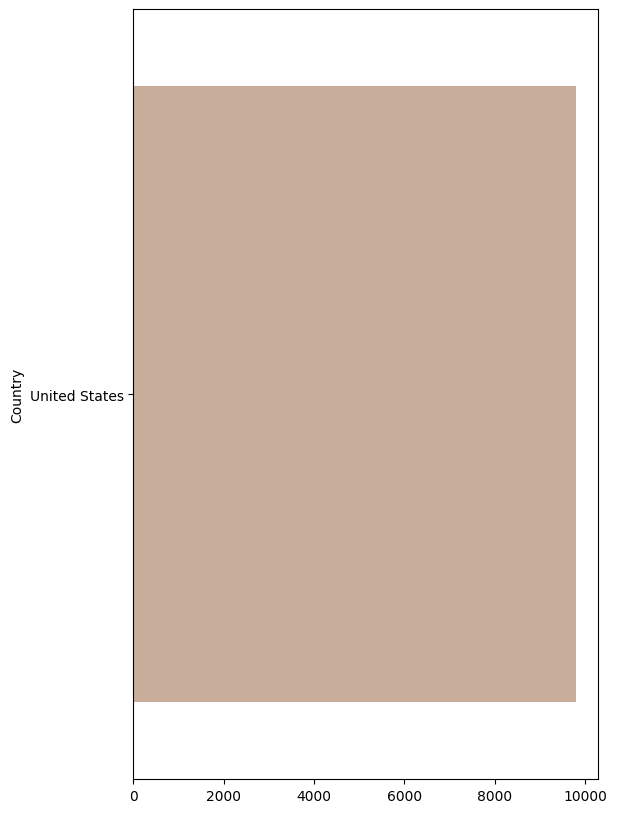

variable: City


/tmp/ipykernel_3062/49709752.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top.values, y=top.index,palette=np.random.choice(paletas_simp))


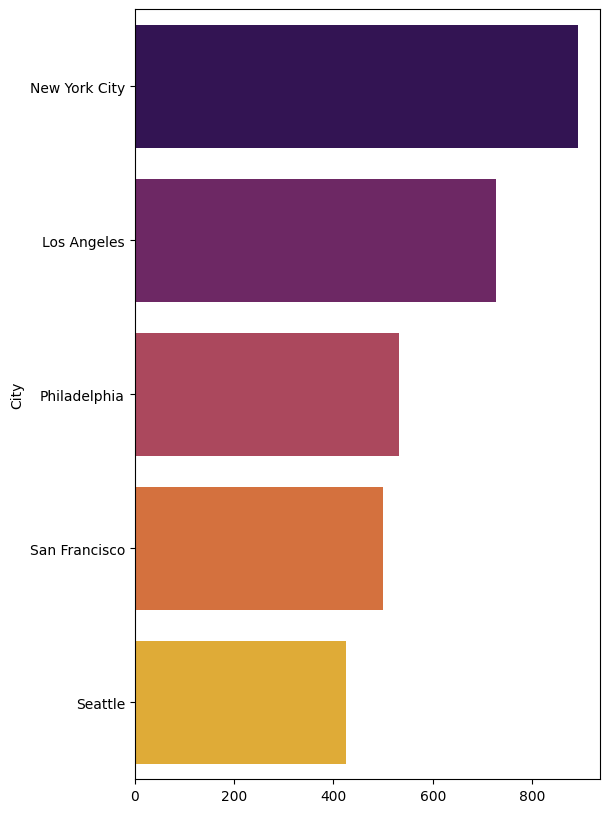

variable: State


/tmp/ipykernel_3062/49709752.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top.values, y=top.index,palette=np.random.choice(paletas_simp))


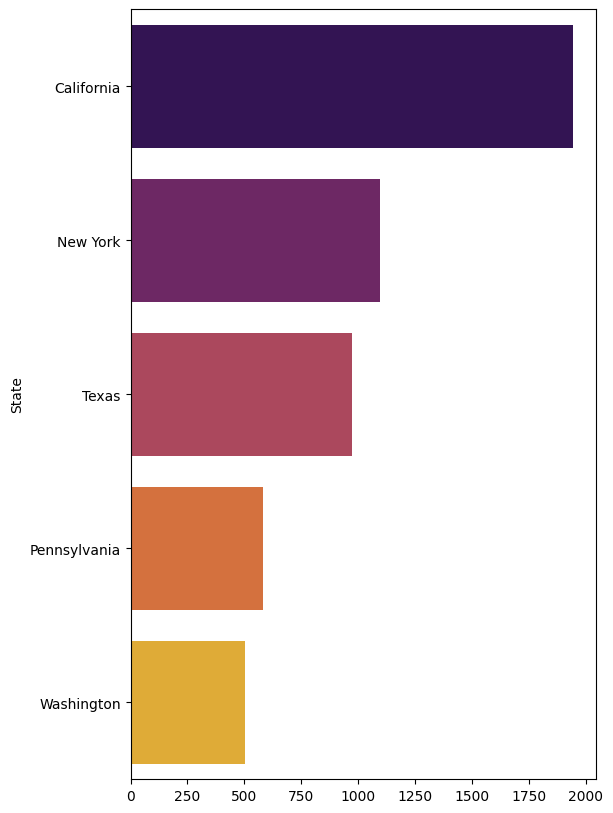

variable :Postal Code


/tmp/ipykernel_3062/49709752.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[x],palette=np.random.choice(paletas_simp))


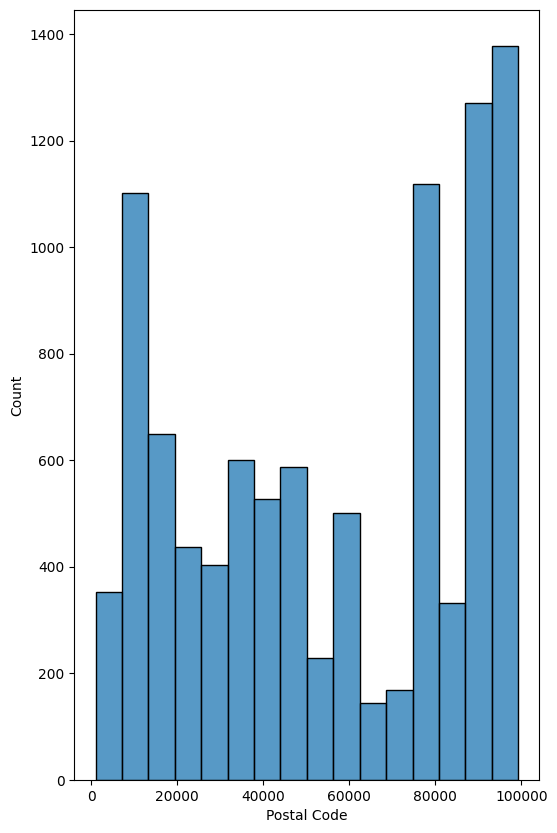

/tmp/ipykernel_3062/49709752.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=df[x],palette=np.random.choice(paletas_simp))


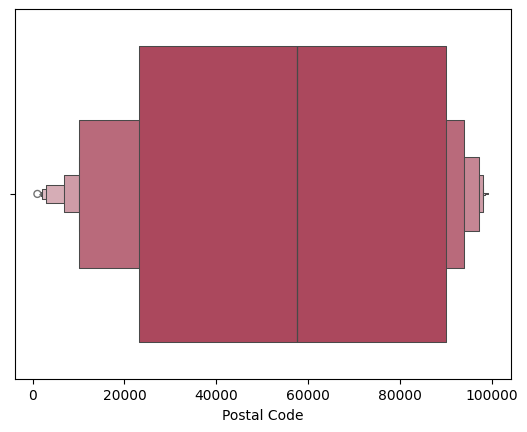

variable: Region


/tmp/ipykernel_3062/49709752.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top.values, y=top.index,palette=np.random.choice(paletas_simp))


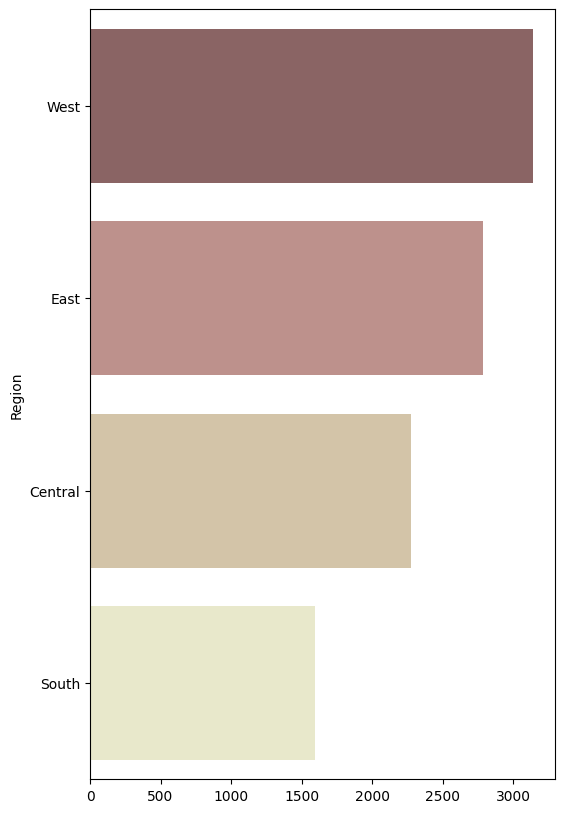

/tmp/ipykernel_3062/49709752.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top.values, y=top.index,palette=np.random.choice(paletas_simp))


variable: Product ID


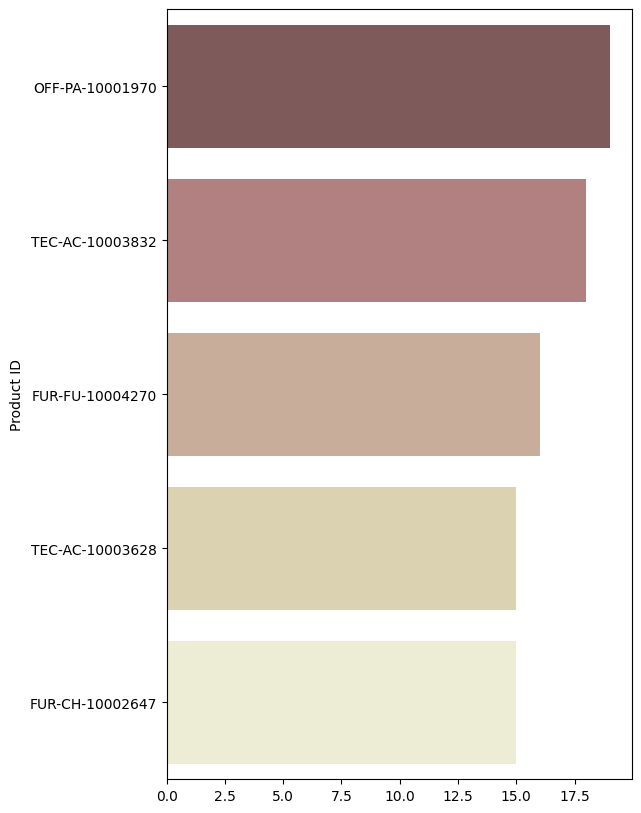

variable: Category


/tmp/ipykernel_3062/49709752.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top.values, y=top.index,palette=np.random.choice(paletas_simp))


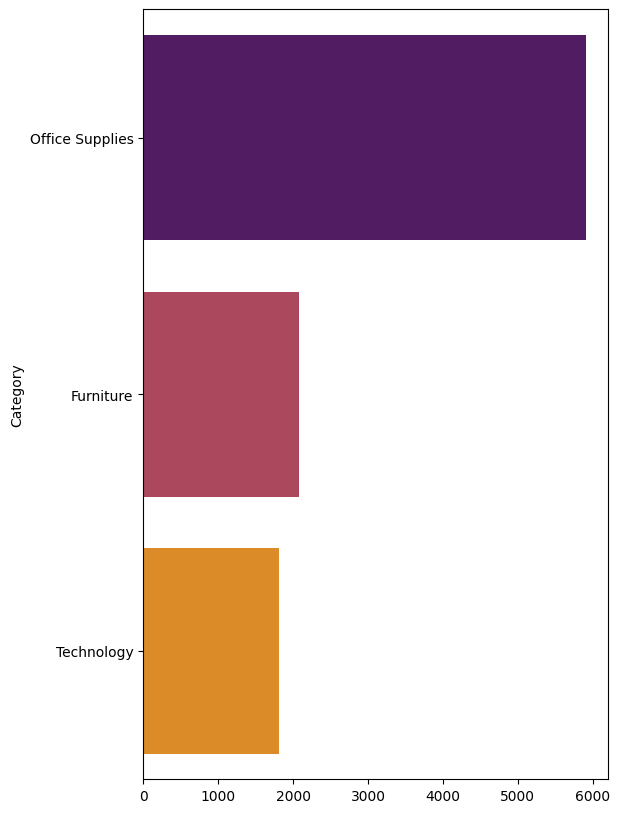

variable: Sub-Category


/tmp/ipykernel_3062/49709752.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top.values, y=top.index,palette=np.random.choice(paletas_simp))


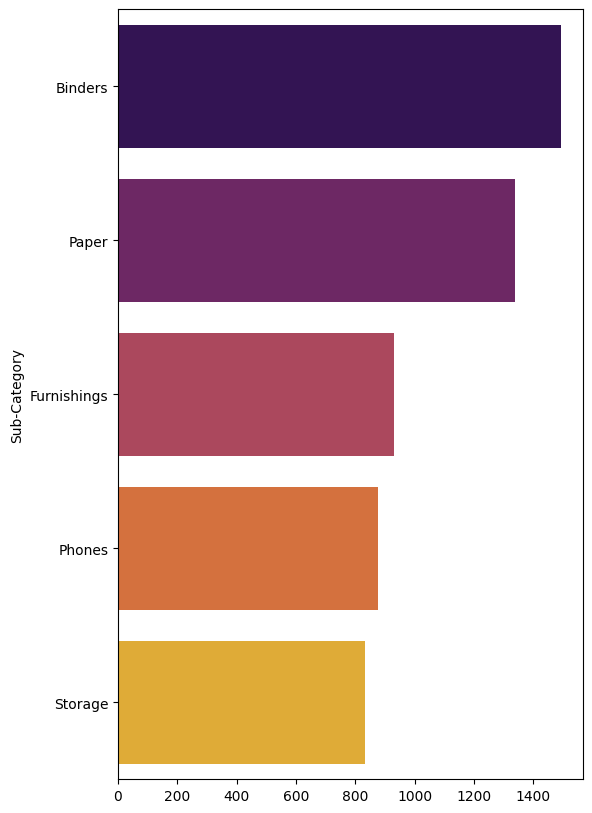

variable: Product Name


/tmp/ipykernel_3062/49709752.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top.values, y=top.index,palette=np.random.choice(paletas_simp))


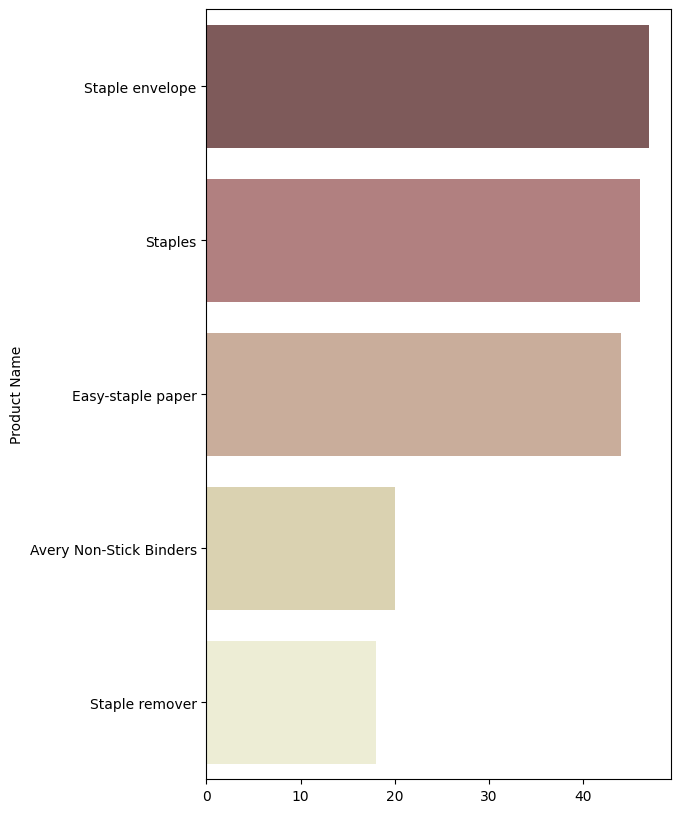

variable :Sales


/tmp/ipykernel_3062/49709752.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[x],palette=np.random.choice(paletas_simp))


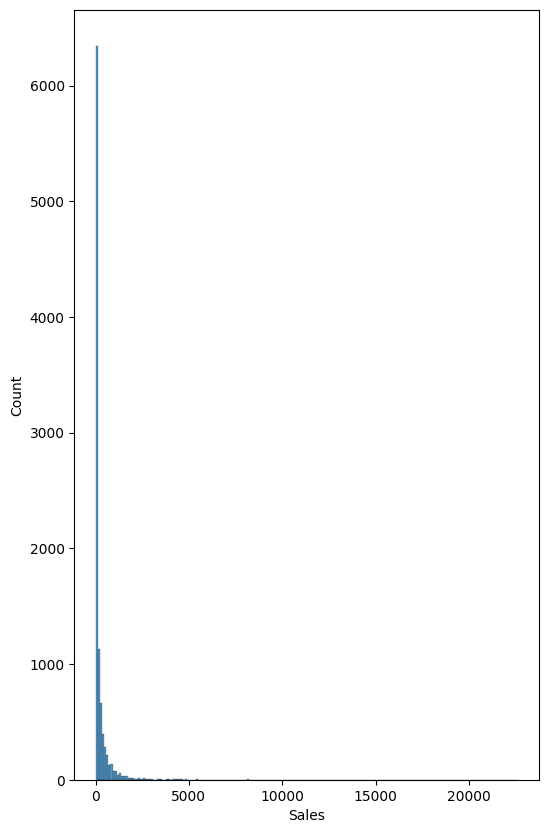

/tmp/ipykernel_3062/49709752.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=df[x],palette=np.random.choice(paletas_simp))


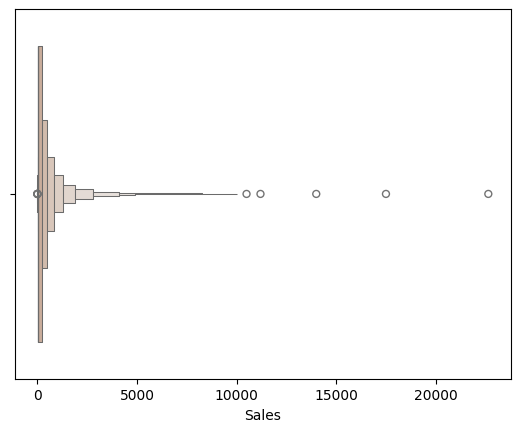

In [14]:
plots(df)

OUTLIERS EN UNIVARIADOS:
ANALISIS A "SALES"

In [15]:
df["Sales"].agg(["mean","median"])

mean      230.769059
median     54.490000
Name: Sales, dtype: float64

comprobamos que existe mucho sesgo

In [16]:
iqr = df["Sales"].quantile(0.75) - df["Sales"].quantile(0.25)
iqr

np.float64(193.35700000000003)

In [17]:
outliers=df.loc[df["Sales"]>df["Sales"].quantile(0.75)+iqr*1.5]

<Axes: xlabel='Sales', ylabel='Count'>

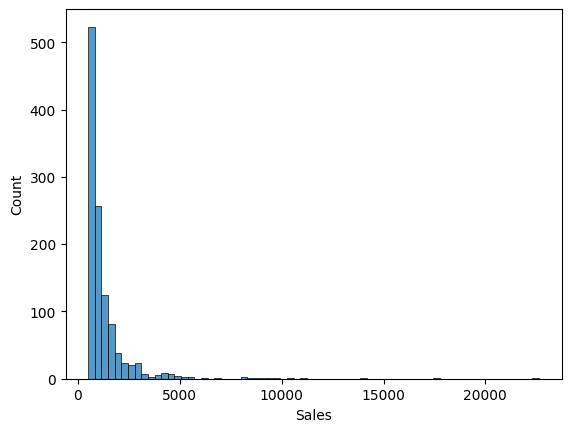

In [18]:
sns.histplot(outliers["Sales"])

La presencia de valores atípicos en la variable Sales indica que existen transacciones con montos significativamente superiores al promedio. Esto puede deberse a productos altamente demandados, compras por volumen o eventos promocionales. También es importante considerar la posibilidad de errores en el registro de datos.

In [19]:
logSales= df["log_sales"] 

KeyError: 'log_sales'

<Axes: xlabel='log_sales', ylabel='Count'>

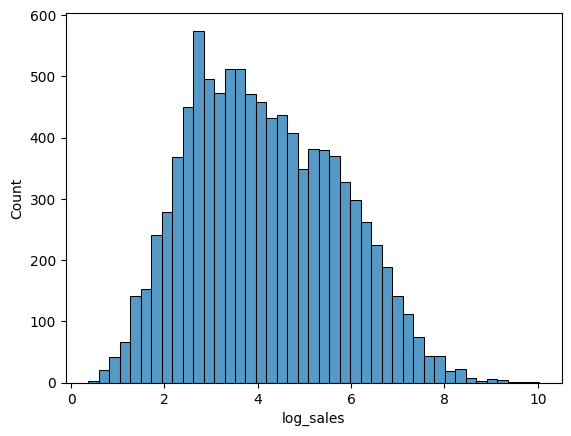

In [ ]:
sns.histplot(logSales)

ANALISIS DE CATEGORIA

QUE CATEGORIA VENDE MAS

In [ ]:
mayor_venta_categoria = df["Category"].value_counts()
mayor_venta_categoria

Category
Office Supplies    5909
Furniture          2078
Technology         1813
Name: count, dtype: int64

/tmp/ipykernel_907/1737414118.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax =sns.barplot(x=mayor_venta_categoria.index,y=mayor_venta_categoria,palette="inferno")


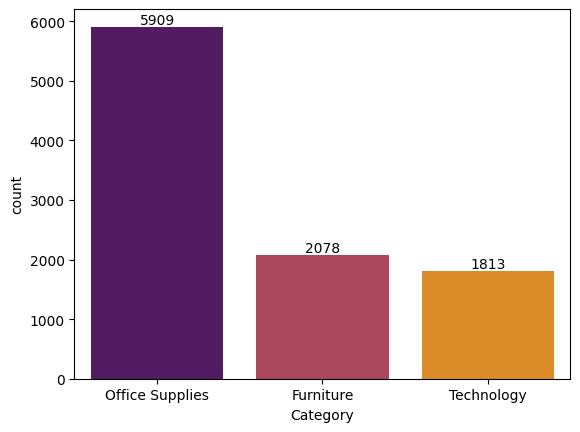

In [ ]:
ax =sns.barplot(x=mayor_venta_categoria.index,y=mayor_venta_categoria,palette="inferno")
for conteiners in ax.containers:
    ax.bar_label(container=conteiners)


Podemos percatarnos que la catgegoria que vende mas es la de Office Suplies

CUAL DEJA MAS GANANCIA?

In [ ]:
mayor_ganancia_categoria = df.groupby("Category")["Sales"].sum()

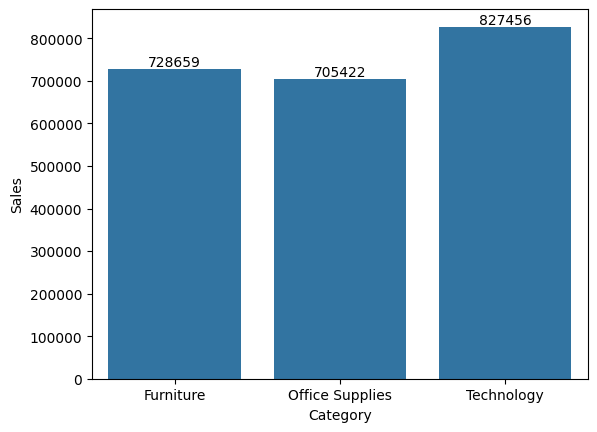

In [ ]:
ax = sns.barplot(x=mayor_ganancia_categoria.index,y=mayor_ganancia_categoria)

for x in ax.containers:
    ax.bar_label(container=x)

Ranking de subcategorías por ventas y por ganancia

In [ ]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'log_sales'],
      dtype='str')

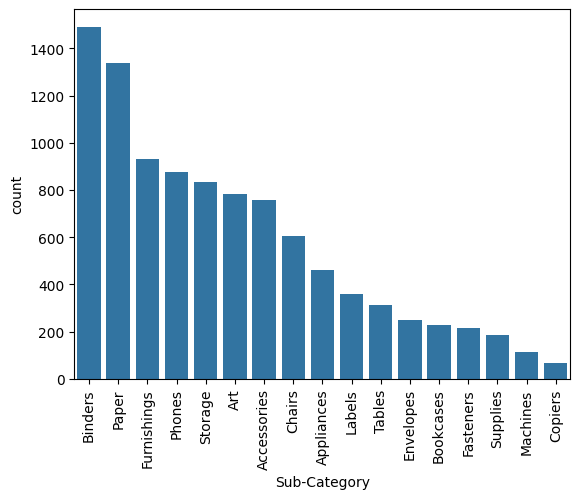

In [ ]:
ventas_sus=df["Sub-Category"].value_counts()
ax2 = sns.barplot(x=ventas_sus.index,y=ventas_sus)
plt.xticks(rotation=90)
for x in ax2.containers:
    ax.bar_label(container=x)

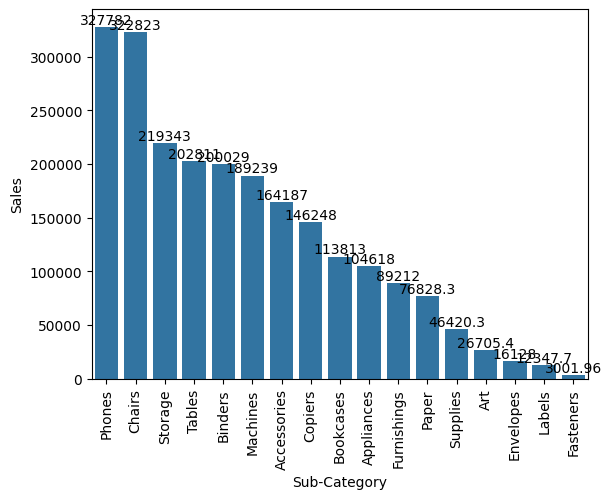

In [ ]:
ganancias_sus = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)
ax3 = sns.barplot(x=ganancias_sus.index,y=ganancias_sus)
plt.xticks(rotation=90)
for x in ax3.containers:
    ax3.bar_label(container=x)

Podemos ver que los celulares generan mayor ganancia

Mayor ventas por región

In [ ]:
ventas_por_region=df["Region"].value_counts()

<Axes: xlabel='Region', ylabel='count'>

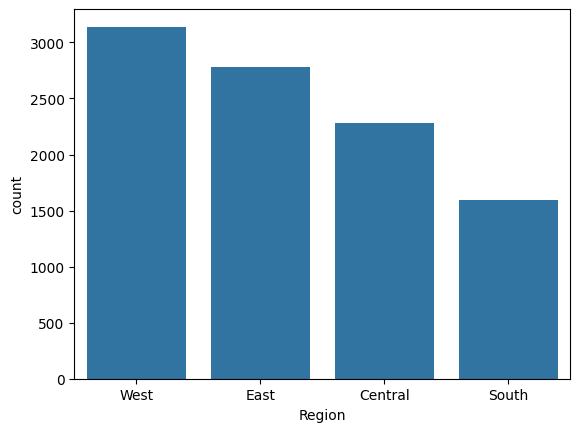

In [ ]:
sns.barplot(x=ventas_por_region.index,y=ventas_por_region)


Mayor ventas por region

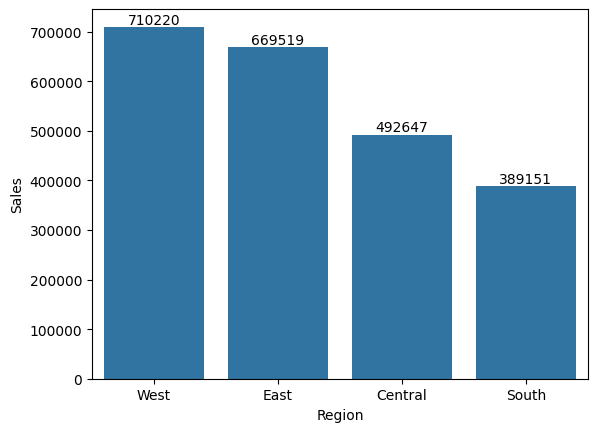

In [22]:
ganancias_por_region=df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
ax=sns.barplot(x=ganancias_por_region.index,y=ganancias_por_region)

for i in ax.containers:
    ax.bar_label(i)

podemos ver que es lo mismo las ganancias que en las ventas
La region mas rentable es west con mas ventas y mas ganancias y la de menor ventas es south con pocas ventas y ganancias 

In [28]:
df["Order Date"]=pd.to_datetime(df["Order Date"],format="%d/%m/%Y")

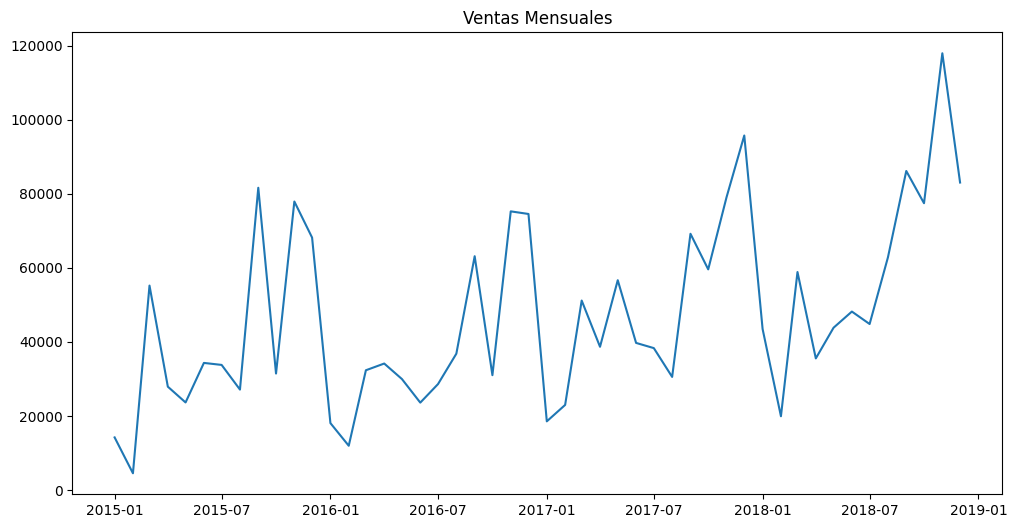

In [ ]:
ventas_mensuales = df.resample("MS", on="Order Date")["Sales"].sum()
plt.figure(figsize=(12,6))
plt.plot(ventas_mensuales)
plt.title("Ventas Mensuales")
plt.show()

Podemos ver que hay estacionalidad, las ventas bajan el primer mes del año pero la tendencia es creciente aunque es poco

In [32]:
df.select_dtypes(include=["int64","float64"]).corr()

,Row ID,Postal Code,Sales
Row ID,1.000000,0.013629,0.001151
Postal Code,0.013629,1.000000,-0.024002
Sales,0.001151,-0.024002,1.000000


es muy dificil encontrar una relacion aqui

HASTA AQUI LLEGO MI MINI-MINI-PROYECTO DE ANALISIS. PROMETO VENIR EN UN FUTURO A MEJORARLO